# Postpartum Depression (PPD) Risk Classification — Model Training

This notebook implements the machine-learning training pipeline described in Chapter Three
of the capstone proposal (sections 3.5.2 Machine-Learning Training Pipeline and 3.5.3 Model
Comparison), and the feature-engineering plan described in section 3.4 (Data Definition and
Acquisition).

**What this notebook does, step by step:**
1. Loads the postpartum depression screening Kaggle
   "PostPartum Depression" dataset as the documented fallback.
2. Screens the data for duplicate/near-duplicate rows, since the Kaggle dataset has a
   documented duplicate-row problem in published research (see section 3.4).
3. Recodes categorical responses onto a consistent ordinal scale.
4. Builds the `risk_level` target (low / medium / high) from a composite symptom severity
   score, keeping the self-harm item separate — it is **not** used as a model feature,
   because Chapter Three specifies that the self-harm question is checked with a simple
   rule (`CrisisCheck`), not by the ML model.
5. Splits the data, balances the training set, and trains four models: Logistic Regression,
   SVM, Random Forest, and XGBoost.
6. Evaluates all four on accuracy, precision, recall, F1-score, and ROC-AUC.
7. Saves the best-performing model as a single bundle that the FastAPI app loads at
   inference time.



## 1. Imports and configuration

In [7]:
import warnings
warnings.filterwarnings("ignore")

import os
import json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = "../data/post_natal_data.csv"   # place the real Kaggle/PRAMS export here
MODEL_OUT_DIR = "../trained_model"
os.makedirs(MODEL_OUT_DIR, exist_ok=True)

print("Setup complete.")


Setup complete.


## 2. Loading the data

The original Kaggle "PostPartum Depression" dataset (Mosaraf, 2023) has these columns:

| Original column | Internal name used below |
|---|---|
| Age | `age_bracket` |
| Feeling sad or Tearful | `feeling_sad` |
| Irritable towards baby & partner | `irritable` |
| Trouble sleeping at night | `trouble_sleeping` |
| Problems concentrating or making decision | `trouble_concentrating` |
| Overeating or loss of appetite | `appetite_changes` |
| Feeling anxious | `feeling_anxious` |
| Feeling of guilt | `feeling_guilty` |
| Problems of bonding with baby | `bonding_difficulty` |
| Suicide attempt | `self_harm_thoughts` |

Most fields take values of `"Yes"`, `"No"`, or `"Sometimes"`. `age_bracket` is a range such
as `"25-30"`.

### Loading your real data
Once you have the real file (downloaded from Kaggle, or exported from PRAMS and mapped to
the same column names), put it at `data/post_natal_data.csv` and simply re-run this
notebook — no other code needs to change. The cell below automatically uses the real file
if present, and only falls back to synthetic data if it is missing.


In [12]:

RENAME_MAP = {
    "Age": "age_bracket",
    "Feeling sad or Tearful": "feeling_sad",
    "Irritable towards baby & partner": "irritable",
    "Trouble sleeping at night": "trouble_sleeping",
    "Problems concentrating or making decision": "trouble_concentrating",
    "Overeating or loss of appetite": "appetite_changes",
    "Feeling anxious": "feeling_anxious",
    "Feeling of guilt": "feeling_guilty",
    "Problems of bonding with baby": "bonding_difficulty",
    "Suicide attempt": "self_harm_thoughts",
}

SYMPTOM_COLS = [
    "feeling_sad", "irritable", "trouble_sleeping", "trouble_concentrating",
    "appetite_changes", "feeling_anxious", "feeling_guilty", "bonding_difficulty",
]
SELF_HARM_COL = "self_harm_thoughts"
AGE_COL = "age_bracket"

if os.path.exists(DATA_PATH):
    raw_df = pd.read_csv(DATA_PATH)
    raw_df = raw_df.rename(columns=RENAME_MAP)
    print(f"Loaded real dataset from {DATA_PATH}: {raw_df.shape[0]} rows.")
else:
    print("Real data file not found at", DATA_PATH)
 

raw_df.head()


Loaded real dataset from ../data/post_natal_data.csv: 1503 rows.


,Timestamp,age_bracket,feeling_sad,irritable,trouble_sleeping,trouble_concentrating,appetite_changes,feeling_anxious,feeling_guilty,bonding_difficulty,self_harm_thoughts
0,6/14/2022 20:02,35-40,Yes,Yes,Two or more days a week,Yes,Yes,Yes,No,Yes,Yes
1,6/14/2022 20:03,40-45,Yes,No,No,Yes,Yes,No,Yes,Yes,No
2,6/14/2022 20:04,35-40,Yes,No,Yes,Yes,Yes,Yes,No,Sometimes,No
3,6/14/2022 20:05,35-40,Yes,Yes,Yes,Yes,No,Yes,Maybe,No,No
4,6/14/2022 20:06,40-45,Yes,No,Two or more days a week,Yes,No,Yes,No,Yes,No


## 3. Data-quality screening (duplicate detection)

Section 3.4 of the proposal flags that the widely used Kaggle PPD dataset has a documented
duplicate-row problem in published research (near-99% accuracies reported elsewhere on this
dataset are an artifact of duplicate rows, not real signal). This step checks for and
removes exact duplicate rows before training, and reports how many were removed — this
number should be reported in Chapter Four whenever this dataset is used.


In [13]:
n_before = len(raw_df)
n_unique_patterns = raw_df.drop_duplicates().shape[0]
n_exact_duplicates = n_before - n_unique_patterns

print(f"Rows before de-duplication: {n_before}")
print(f"Exact duplicate rows found: {n_exact_duplicates}")
print(f"Rows after removing exact duplicates: {n_unique_patterns}")

if n_exact_duplicates / max(n_before, 1) > 0.05:
    print()
    print("WARNING: more than 5% of rows are exact duplicates. This matches the")
    print("duplicate-leakage issue documented for this dataset in prior literature.")
    print("Any accuracy figure from this data should be reported alongside this warning.")

df = raw_df.drop_duplicates().reset_index(drop=True)


Rows before de-duplication: 1503
Exact duplicate rows found: 1088
Rows after removing exact duplicates: 415

duplicate-leakage issue documented for this dataset in prior literature.
Any accuracy figure from this data should be reported alongside this warning.


## 4. Feature engineering

Following the plan in section 3.4:
1. Recode `"No"/"Sometimes"/"Yes"` responses to an ordinal scale (0 / 1 / 2).
2. Recode `age_bracket` to an ordinal scale.
3. Compute a composite **symptom severity score** from the 8 symptom items
   (`SYMPTOM_COLS`) — the self-harm item is deliberately excluded here, since Chapter
   Three specifies it is handled separately by a rule-based `CrisisCheck`, not by the ML
   model.
4. Derive the `risk_level` target (`low` / `medium` / `high`) from the severity score.

**Note on thresholds**: because this dataset does not use the validated EPDS scale (which
has an established clinical cutoff), tercile-based cutoffs (roughly equal-sized groups) are
used here as a defensible interim approach. If PRAMS access is granted and its data includes
an EPDS-scored item, the standard EPDS clinical cutoff (commonly ≥13) should be used instead
— this should be noted explicitly in Chapter Four.


In [14]:
ORDINAL_MAP = {"No": 0, "Sometimes": 1, "Yes": 2}
AGE_ORDER = ["25-30", "30-35", "35-40", "40-45", "45-50"]
AGE_MAP = {bracket: i for i, bracket in enumerate(AGE_ORDER)}

fe_df = df.copy()

for col in SYMPTOM_COLS + [SELF_HARM_COL]:
    fe_df[col] = fe_df[col].map(ORDINAL_MAP)

fe_df[AGE_COL] = fe_df[AGE_COL].map(AGE_MAP)

# drop rows where mapping failed (unexpected category not in ORDINAL_MAP/AGE_MAP)
before_drop = len(fe_df)
fe_df = fe_df.dropna(subset=SYMPTOM_COLS + [SELF_HARM_COL, AGE_COL]).reset_index(drop=True)
if before_drop != len(fe_df):
    print(f"Dropped {before_drop - len(fe_df)} rows with unmapped/unexpected category values.")

fe_df["symptom_severity_score"] = fe_df[SYMPTOM_COLS].sum(axis=1)

q1, q2 = fe_df["symptom_severity_score"].quantile([1/3, 2/3])
print(f"Tercile cutoffs on this dataset -> low/medium boundary: {q1:.1f}, medium/high boundary: {q2:.1f}")

def score_to_risk(score):
    if score <= q1:
        return "low"
    elif score <= q2:
        return "medium"
    else:
        return "high"

fe_df["risk_level"] = fe_df["symptom_severity_score"].apply(score_to_risk)

print()
print("Risk level distribution:")
print(fe_df["risk_level"].value_counts())

FEATURE_COLS = SYMPTOM_COLS + [AGE_COL]   # self_harm_thoughts intentionally excluded
fe_df[FEATURE_COLS + ["symptom_severity_score", "risk_level"]].head()


Dropped 343 rows with unmapped/unexpected category values.
Tercile cutoffs on this dataset -> low/medium boundary: 7.0, medium/high boundary: 8.0

Risk level distribution:
risk_level
low       33
high      23
medium    16
Name: count, dtype: int64


,feeling_sad,irritable,trouble_sleeping,trouble_concentrating,appetite_changes,feeling_anxious,feeling_guilty,bonding_difficulty,age_bracket,symptom_severity_score,risk_level
0,2,0.0,0.0,2.0,2.0,0,2.0,2,3,10.0,high
1,2,0.0,2.0,2.0,2.0,2,0.0,1,2,11.0,high
2,0,0.0,2.0,2.0,2.0,2,0.0,0,1,8.0,medium
3,0,2.0,0.0,0.0,0.0,2,0.0,0,3,4.0,low
4,2,0.0,2.0,2.0,0.0,2,0.0,0,2,8.0,medium


## 5. Train/test split

In [15]:
X = fe_df[FEATURE_COLS]
y = fe_df["risk_level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train class balance:")
print(y_train.value_counts(normalize=True).round(2))
print()
print("Test class balance:")
print(y_test.value_counts(normalize=True).round(2))


Train class balance:
risk_level
low       0.46
high      0.32
medium    0.23
Name: proportion, dtype: float64

Test class balance:
risk_level
low       0.47
high      0.33
medium    0.20
Name: proportion, dtype: float64


## 6. Balancing the training set (SMOTE)

Only the **training set** is balanced — the test set is left with its original, realistic
class distribution so that evaluation reflects real-world performance.


In [16]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Training class balance after SMOTE:")
print(y_train_bal.value_counts())


Training class balance after SMOTE:
risk_level
high      26
medium    26
low       26
Name: count, dtype: int64


## 7. Model comparison: XGBoost, Random Forest, SVM, Logistic Regression

In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(["low", "medium", "high"])
y_train_enc = le.transform(y_train_bal)
y_test_enc = le.transform(y_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "SVM": SVC(probability=True, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(
        n_estimators=300, use_label_encoder=False, eval_metric="mlogloss",
        random_state=RANDOM_STATE
    ),
}

results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_bal, y_train_enc)
    fitted_models[name] = model

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    acc = accuracy_score(y_test_enc, y_pred)
    prec = precision_score(y_test_enc, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_test_enc, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_test_enc, y_pred, average="macro", zero_division=0)
    y_test_bin = label_binarize(y_test_enc, classes=[0, 1, 2])
    auc = roc_auc_score(y_test_bin, y_proba, average="macro", multi_class="ovr")

    results.append({
        "model": name, "accuracy": acc, "precision_macro": prec,
        "recall_macro": rec, "f1_macro": f1, "roc_auc_macro": auc,
    })

results_df = pd.DataFrame(results).set_index("model").round(3)
results_df


,accuracy,precision_macro,recall_macro,f1_macro,roc_auc_macro
model,,,,,
Logistic Regression,0.800,0.725,0.711,0.711,0.931
SVM,0.667,0.667,0.597,0.612,0.901
Random Forest,0.800,0.759,0.711,0.721,0.932
XGBoost,0.800,0.786,0.775,0.772,0.869


### 7.1 Comparison chart

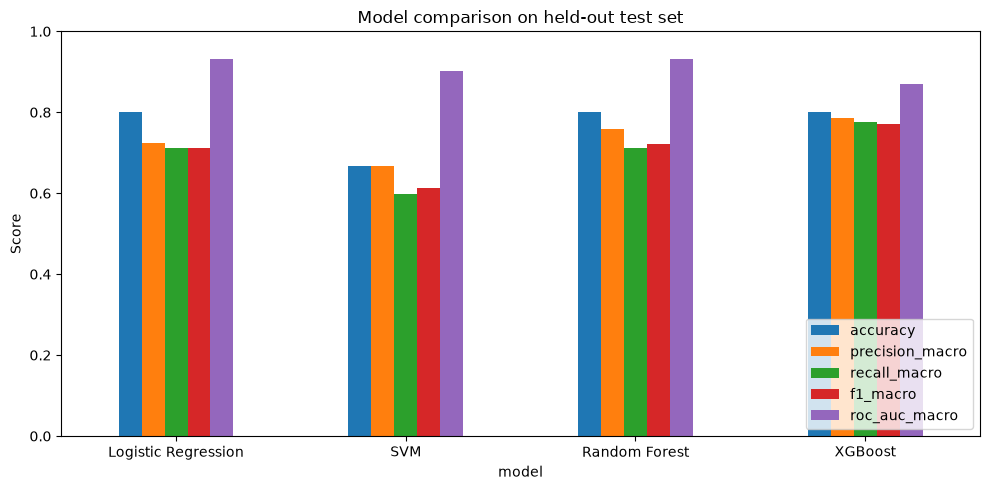

In [18]:
results_df[["accuracy", "precision_macro", "recall_macro", "f1_macro", "roc_auc_macro"]].plot(
    kind="bar", figsize=(10, 5), rot=0
)
plt.title("Model comparison on held-out test set")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../trained_model/model_comparison.png", dpi=120)
plt.show()


### 7.2 Confusion matrices

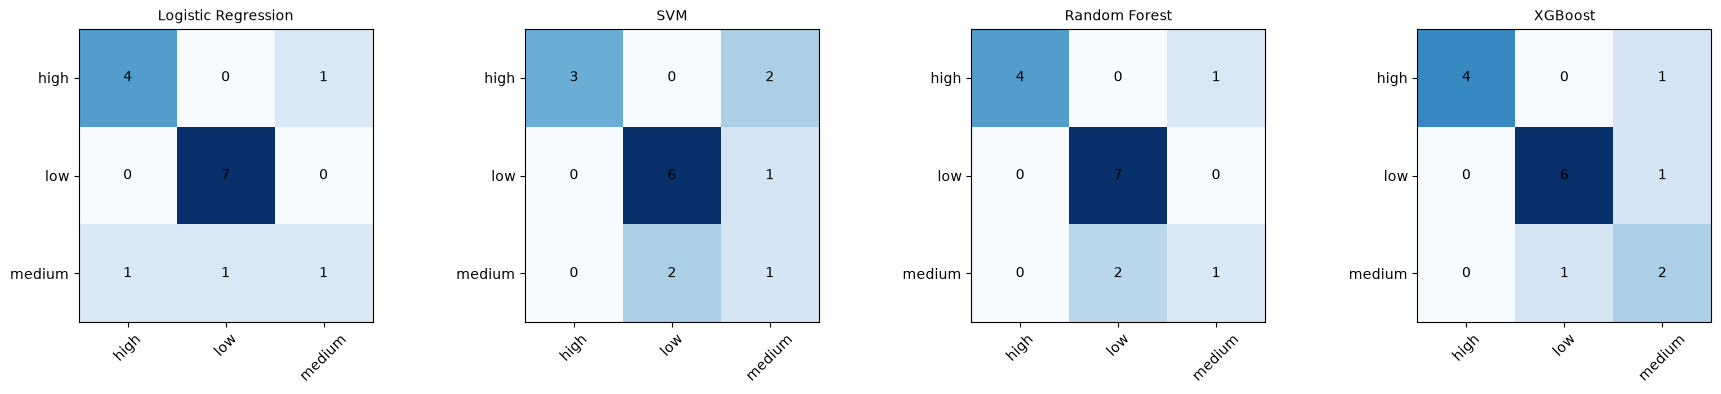

In [19]:
fig, axes = plt.subplots(1, len(models), figsize=(18, 4))
for ax, (name, model) in zip(axes, fitted_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test_enc, y_pred)
    ax.imshow(cm, cmap="Blues")
    ax.set_title(name, fontsize=10)
    ax.set_xticks(range(3)); ax.set_xticklabels(le.classes_, rotation=45)
    ax.set_yticks(range(3)); ax.set_yticklabels(le.classes_)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.savefig("../trained_model/confusion_matrices.png", dpi=120)
plt.show()


## 8. Selecting and saving the best model

The best model is selected by macro F1-score, since the classes are imbalanced and F1
balances precision and recall — consistent with section 2.2.4's note that recall matters
most clinically, while precision keeps false alarms in check.


In [20]:
best_name = results_df["f1_macro"].idxmax()
best_model = fitted_models[best_name]
print(f"Best model: {best_name}")
print(results_df.loc[best_name])

model_bundle = {
    "model": best_model,
    "model_name": best_name,
    "label_encoder": le,
    "feature_cols": FEATURE_COLS,
    "ordinal_map": ORDINAL_MAP,
    "age_map": AGE_MAP,
    "risk_thresholds": {"low_max": float(q1), "medium_max": float(q2)},
    "trained_on": "synthetic_demo" if not os.path.exists(DATA_PATH) else "real_data",
}

bundle_path = os.path.join(MODEL_OUT_DIR, "model_bundle.joblib")
joblib.dump(model_bundle, bundle_path)
print(f"Saved model bundle to {bundle_path}")

with open(os.path.join(MODEL_OUT_DIR, "metrics.json"), "w") as f:
    json.dump(results_df.reset_index().to_dict(orient="records"), f, indent=2)
print("Saved metrics.json")


Best model: XGBoost
accuracy           0.800
precision_macro    0.786
recall_macro       0.775
f1_macro           0.772
roc_auc_macro      0.869
Name: XGBoost, dtype: float64
Saved model bundle to ../trained_model\model_bundle.joblib
Saved metrics.json


## 9. Feature importance (best tree-based model)

A quick, non-SHAP feature importance view for whichever tree-based model performed best,
to sanity-check that the symptom items driving predictions make clinical sense. This is a
lighter-weight companion to the SHAP-based explainability approach discussed in section
2.3.2 of the literature review, which is a natural extension for Chapter Four/Five.


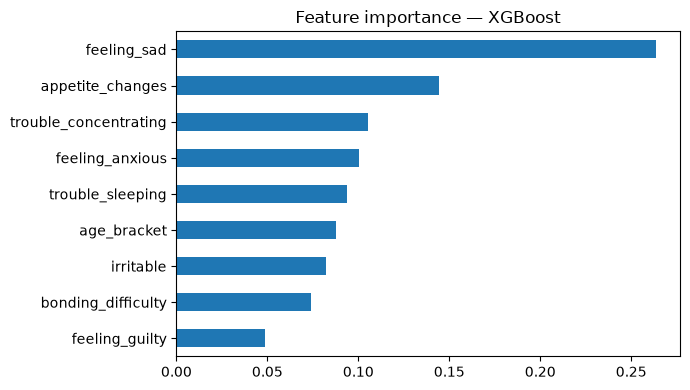

In [21]:
if best_name in ("Random Forest", "XGBoost"):
    importances = pd.Series(best_model.feature_importances_, index=FEATURE_COLS)
    importances.sort_values().plot(kind="barh", figsize=(7, 4))
    plt.title(f"Feature importance — {best_name}")
    plt.tight_layout()
    plt.savefig("../trained_model/feature_importance.png", dpi=120)
    plt.show()
else:
    print(f"{best_name} does not expose .feature_importances_ directly; "
          "use permutation importance or SHAP's KernelExplainer for this model type.")
